In [1]:
import argparse
import os

import pandas as pd
import pickle
from tqdm import tqdm
from copy import deepcopy

import numpy as np
import torch
from torch import optim
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt

import sys

from utils import *

In [2]:
from data_utils import load_data_all, load_data_syn

dataset = 'douban'
sample_col = 300
print(dataset)
if dataset == 'random':
    r = 5
    d1 = 5000
    d2 = 200
    _, _, M = load_data_syn(r, d1, d2)
else:
    M = load_data_all(dataset, sample_col)
    M = M.float()
    d1, d2 = M.shape

num = (M!=0).sum()
print(f"entries num: {num}")
print(M.shape)


douban
entries num: 13647
torch.Size([3000, 300])


3000
300
0.75
epochs: 500
alpha: 0.001
eta: 500
noise: 0.0


/tmp/ipykernel_894435/29900643.py:116: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  M = torch.tensor(M).float()


norm of M: 444.4805908203125


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:07<00:00, 64.52it/s, In epoch 499, loss: 7.447)]  


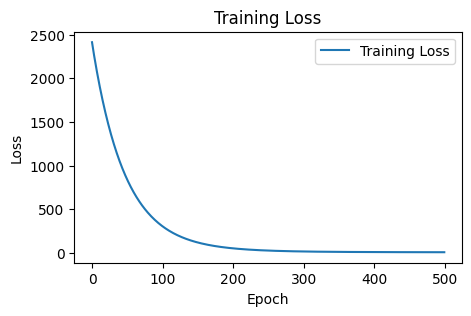

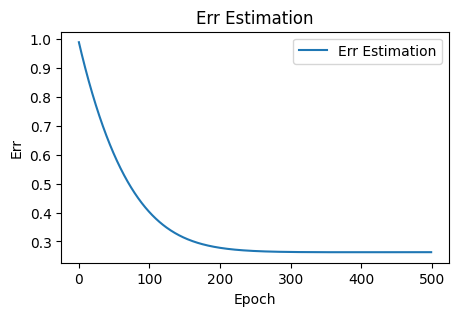

In [3]:
device = 'cuda:0'
p=0.75
print(d1)
print(d2)
print(p)
if dataset == 'random':
    if d1 == 5000:
        if p == 0.1:
            epochs = 4000
            alpha = 1
            eta = 100
            noise = 0.1
        if p == 0.5:
            epochs = 500
            alpha = 0.1
            eta = 50
            noise = 0.1
        if p == 0.75:
            epochs = 2000
            alpha = 0.1
            eta = 50
            noise = 0.1
    elif d1 == 10000:
        if p == 0.25:
            epochs = 500
            alpha = 0.1
            eta = 100
            noise = 0
        if p == 0.5:
            epochs = 500
            alpha = 0.1
            eta = 100
            noise = 0
        if p == 0.75:
            epochs = 2000
            alpha = 1
            eta = 50
            noise = 1
    elif d1 == 15000:
        if p == 0.25:
            epochs = 500
            alpha = 0.1
            eta = 100
            noise = 0
        if p == 0.5:
            epochs = 500
            alpha = 0.1
            eta = 100
            noise = 0
        if p == 0.75:
            epochs = 2000
            alpha = 1
            eta = 50
            noise = 1
elif dataset == 'ml-1m':
    p = 0.75
    r = 5
    epochs = 4000
    alpha = 1
    eta = 50
    noise = 0.01
elif dataset =='netflix':
    p = 0.75
    r = 5
    epochs = 4000
    alpha = 0.1
    eta = 50
    noise = 0.01
elif dataset =='gene':
    p = 0.75
    r = 5
    epochs = 500
    alpha = 0.1
    eta = 50
    noise = 0.1
elif dataset == 'douban':
    p = 0.75
    r = 5
    epochs = 500
    alpha = 0.001
    eta = 500
    noise = 0.000
elif dataset == 'flixster':
    p = 0.75
    r = 5
    epochs = 500
    alpha = 0.001
    eta = 500
    noise = 0.001
elif dataset == 'yahoo_music':
    p = 0.75
    r = 5
    epochs = 500
    alpha = 0.001
    eta = 500
    noise = 0.001
elif dataset == 'sweet':
    p = 0.75
    r = 5
    epochs = 500
    alpha = 0.1
    eta = 50
    noise = 0.1
print(f"epochs: {epochs}")
print(f"alpha: {alpha}")
print(f"eta: {eta}")
print(f"noise: {noise}")
"""
Train for X
"""


runs = 1
X_list = []
for run in range(runs):
    M = torch.tensor(M).float()
    mask = torch.bernoulli(torch.full((M.shape[0],), 1-p)).bool()
    Omega = torch.rand(d1, d2, device = device) <= p
    # observed M & norm
    M = M.to(device)
    observed_M = deepcopy(M) * Omega

    MTM = observed_M.t() @ observed_M
    norm = torch.norm(MTM)

    scale_diag = (p - 1) / (p ** 2) * torch.diag(MTM).diag() # objective matrix
    A = scale_diag + 1 / (p ** 2) * MTM

    print(f"norm of M: {torch.norm(M)}")
    # parameters setting
    X = torch.randn(d2, d2, requires_grad=True, device=device)

    loop = tqdm(range(epochs))
    optimizer = optim.SGD([X], lr=eta)

    # opt
    train_losses = []
    err_estimates = []
    #writer = SummaryWriter('runs/'+dataset)
    for i in loop:
        loss = ((X - A)**2).mean() # mse loss
        with torch.no_grad():
            U, D, Vt = torch.linalg.svd(X.detach(), full_matrices=False)
        loss.backward()

        noise_matrix = torch.normal(mean=0, std=noise, size=(d2, d2), device=device)

        X.grad = X.grad + alpha * U @ Vt + noise_matrix # alg
        """
        with torch.no_grad():
            X.data += -eta*X.grad
        """
        optimizer.step()
        X.grad.zero_()
        train_losses.append(loss.item())
        err = X - M.T @ M
        err_estimates.append((torch.norm(err)/torch.norm(M.T @ M)).item())
        loop.set_postfix_str('In epoch {}, loss: {:.3f})'.format(i, loss.item()))
    X_list.append(X.detach())

plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(err_estimates, label='Err Estimation')
plt.xlabel('Epoch')
plt.ylabel('Err')
plt.title('Err Estimation')
plt.legend()

#np.save(f'temp2/train_loss_{str(alpha)}.npy', train_losses)
#np.save(f'temp2/err_estimates_{str(alpha)}.npy', err_estimates)

In [4]:
"""
Compute X-MTM
"""
G_list = []
for X in X_list:
    err = X - M.T @ M
    print(torch.norm(err), torch.norm(M.T @ M))
    print(torch.norm(X))
    print(torch.norm(err)/torch.norm(M.T @ M))
    G_list.append((torch.norm(err)/torch.norm(M.T @ M)).item())

print(np.mean(G_list))
print(np.std(G_list))

tensor(3806.2200, device='cuda:0') tensor(14469.7656, device='cuda:0')
tensor(14089.2500, device='cuda:0')
tensor(0.2630, device='cuda:0')
0.26304641366004944
0.0


In the case r=1, use every column to recover M independently. If M can be retrieved, the result should be similar in every column.

The key is the gap between estimated r and real r

In [5]:
#miss_users = torch.tensor(range(M.shape[0]))[mask]
miss_users = torch.tensor(range(M.shape[0]))
predict_matrix = []
miss_item_u = []
error_list = []
test_num = 0
result_list = []
total_num = 0
skip = 0
result_list_test = []
result_list_total = []

for X in X_list:
    _, S, item_vector = top_r_svd(X, r)
    for i in tqdm(range(miss_users.shape[0])):
        """
        M_u: 1*d2
        item_vector: r*d2
        useR_vector: 1*r
        """
        M_u = M[miss_users][i].float()
        #non_zero_indices = M_u.nonzero(as_tuple=True)[0]
        non_zero_indices = torch.tensor(range(M_u.shape[0]))

        train_idx = []
        test_idx = []
        for idx in non_zero_indices:
            if Omega[i][idx]:
                train_idx.append(idx.item())
            else:
                test_idx.append(idx.item())
        # train mask
        M_u = M_u.unsqueeze(0)
        n = non_zero_indices.shape[0]
        selected_indices = torch.tensor(train_idx)
        non_selected_indices = torch.tensor(test_idx)
        if len(test_idx)==0 or len(train_idx) == 0:
            skip +=1
            continue
        test_num += len(test_idx)
        total_num += len(test_idx) + len(train_idx)

        train_A = item_vector[:, selected_indices]
        train_B = M_u[:, selected_indices]
        test_A = item_vector[:, non_selected_indices]
        test_B = M_u[:, non_selected_indices]

        # 正则化参数
        lambda_reg = 0.01
        I = torch.eye(train_A.shape[0], device=device) * lambda_reg

        # 岭回归求解
        u = torch.linalg.lstsq(train_A @ train_A.t() + I, train_A @ train_B.t()).solution.t()

        error_list.append(torch.sum((u @ test_A - test_B)**2).item())
        
    ret = np.sqrt(np.sum(error_list)/test_num)
    result_list_test.append(np.sqrt(np.sum(error_list)/test_num))
    result_list_total.append(np.sqrt(np.sum(error_list)/total_num))
print(np.mean(result_list_test))
print(np.std(result_list_test))
print(np.mean(result_list_total))
print(np.std(result_list_total))




  4%|▍         | 128/3000 [00:01<00:25, 111.47it/s]

100%|██████████| 3000/3000 [00:28<00:00, 104.27it/s]

0.4738998284061814
0.0
0.23720094813460305
0.0
